In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

In [21]:
demographic = pd.read_csv('cleaned dataset/api_data_aadhar_demographic.csv')

In [22]:
features = [ 'age between 5 and 17', 'age 17 and above']

In [23]:
# Summing up activity over time to get a total profile for each district
district_data = demographic.groupby('district')[features].sum().reset_index()

In [24]:
# We must scale the data because 'Adult Updates' might be 10x larger than 'Births'.
# Without scaling, the algorithm would ignore births entirely.
scaler = StandardScaler()
data_scaled = scaler.fit_transform(district_data[features])

In [25]:
# We request exactly 3 clusters as per your business requirement
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
district_data['Cluster_Label'] = kmeans.fit_predict(data_scaled)

In [27]:
# The algorithm gives labels 0, 1, 2. We must figure out what they mean.
# We look at the average values of the original features for each cluster.
summary = district_dna.groupby('Cluster_Label')[features].mean()

summary_norm = summary / summary.max()

print(summary)
print(summary_norm)

               age between 5 and 17  age 17 and above
Cluster_Label                                        
0                       2236.474245      18984.490231
1                       9522.151020      92215.053061
2                      22702.892857     199121.517857
               age between 5 and 17  age 17 and above
Cluster_Label                                        
0                          0.098511          0.095341
1                          0.419425          0.463109
2                          1.000000          1.000000


In [31]:
cluster_names = {}

for cluster_id, row in summary_norm.iterrows():
    adult_score = row['age 17 and above']
    kid_score = row['age between 5 and 17']
    
    # Logic to name the clusters based on their intensity
    if adult_score < 0.3 and kid_score < 0.3:
        cluster_names[cluster_id] = "Quiet District (Low Resources)"
    elif adult_score > kid_score:
        cluster_names[cluster_id] = "Workforce Hub (High Migration)"
    else:
        cluster_names[cluster_id] = "Family Zone (High School Demand)"

district_data['Profile'] = district_data['Cluster_Label'].map(cluster_names)

# Fallback: If logic misses (e.g., both are High), default to "High Intensity Hub"
district_data['Profile'].fillna('High Intensity Hub', inplace=True)

display(district_data)

C:\Users\LENOVO\AppData\Local\Temp\ipykernel_20140\472104186.py:18: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  district_data['Profile'].fillna('High Intensity Hub', inplace=True)


,district,age between 5 and 17,age 17 and above,Cluster_Label,Profile
0,5Th Cross,0,1,0,Quiet District (Low Resources)
1,Adilabad,9009,66292,1,Workforce Hub (High Migration)
2,Agar Malwa,965,8919,0,Quiet District (Low Resources)
3,Agra,18477,157476,2,Family Zone (High School Demand)
4,Ahilyanagar,200,2218,0,Quiet District (Low Resources)
...,...,...,...,...,...
859,Yadgir,7220,28213,0,Quiet District (Low Resources)
860,Yamunanagar,6448,46861,0,Quiet District (Low Resources)
861,Yanam,11,302,0,Quiet District (Low Resources)
862,Yavatmal,5104,191008,1,Workforce Hub (High Migration)


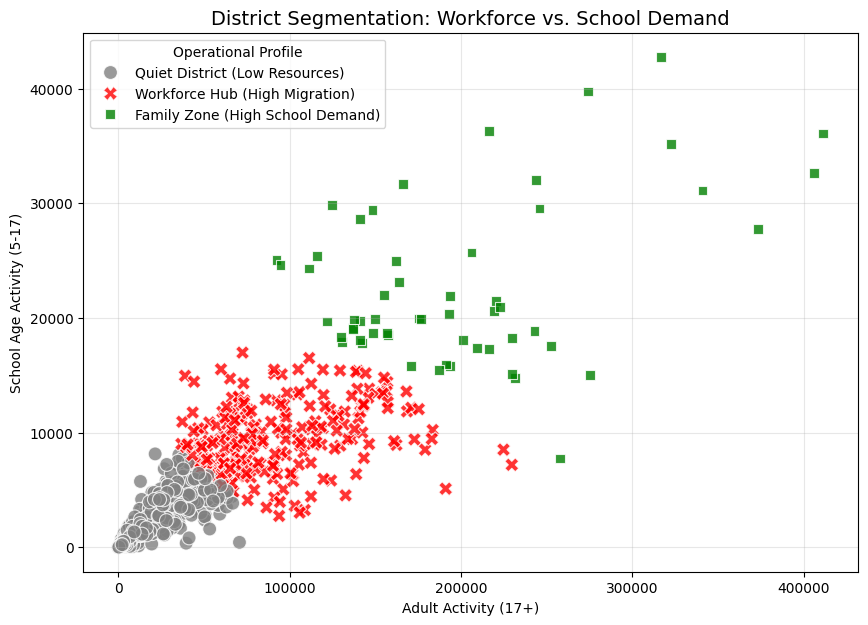

In [33]:
# 6. Visualization
plt.figure(figsize=(10, 7))

# Plotting Raw Data (Standardized not needed for visual, but good for relative scale)
# We plot the LOG scale if the numbers are huge, but linear is fine for segmentation view
sns.scatterplot(
    data=district_dna, 
    x='age 17 and above', 
    y='age between 5 and 17', 
    hue='Profile', 
    style='Profile',
    palette={'Workforce Hub (High Migration)': 'red', 
             'Family Zone (High School Demand)': 'green', 
             'Quiet District (Low Resources)': 'grey',
             'High Intensity Hub': 'blue'},
    s=100, alpha=0.8
)

plt.title('District Segmentation: Workforce vs. School Demand', fontsize=14)
plt.xlabel('Adult Activity (17+)')
plt.ylabel('School Age Activity (5-17)')
plt.legend(title='Operational Profile')
plt.grid(True, alpha=0.3)
plt.show()

In [ ]:
# 7. Export for Power BI
district_dna.to_csv('district_clusters_2var.csv', index=False)
print("Segmentation Complete. File 'district_clusters_2var.csv' generated.")
print(district_dna['Profile'].value_counts())

Power BI Implementation
Since you are using 2 variables, the visualization in Power BI is very intuitive.

The Visual: Select Scatter Chart.

X-Axis: Drag age 17 and above. (This shows Workforce size).

Y-Axis: Drag age 5 to 17. (This shows School demand).

Legend: Drag Profile. (This colors the dots: Red for Workforce, Green for Family, Grey for Quiet).

Details: Drag district.

What you will see:

A "Fan" Shape:

Steep Slope (Green dots): Districts where for every 1 adult, there are many kids. Strategy: Invest in Schools/Scholarships.

Flat Slope (Red dots): Districts with tons of adults but very few kids. Strategy: Invest in Migration Support/Housing (schools are low priority).

Bottom Left (Grey dots): Small districts that need minimal maintenance.